# Import Library dan Menghubungkan Drive

In [ ]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import cv2
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from google.colab import drive

drive.mount('/content/drive')
base_dir = '/content/drive/My Drive/Capstone DBS Foundation/Projects/DATASET'
train_dir = os.path.join(base_dir, 'TRAIN')
test_dir = os.path.join(base_dir, 'TEST')

IMG_SIZE = 224
BATCH_SIZE = 32

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# Fungsi Pengecekan

In [ ]:
def count_files(directory):
    counts = {'O': 0, 'R': 0}
    for label in ['O', 'R']:
        path = os.path.join(directory, label)
        if os.path.exists(path):
            counts[label] = len(os.listdir(path))
        else:
            print(f"Peringatan: Folder {path} tidak ditemukan!")
    return counts

# Eksekusi & Visualisasi

Peringatan: Folder /content/drive/My Drive/Capstone DBS Foundation/Projects/DATASET/TRAIN/O tidak ditemukan!
Peringatan: Folder /content/drive/My Drive/Capstone DBS Foundation/Projects/DATASET/TRAIN/R tidak ditemukan!
Peringatan: Folder /content/drive/My Drive/Capstone DBS Foundation/Projects/DATASET/TEST/O tidak ditemukan!
Peringatan: Folder /content/drive/My Drive/Capstone DBS Foundation/Projects/DATASET/TEST/R tidak ditemukan!
Data Training - Organik (O): 0
Data Training - Anorganik (R): 0
Data Testing  - Organik (O): 0
Data Testing  - Anorganik (R): 0


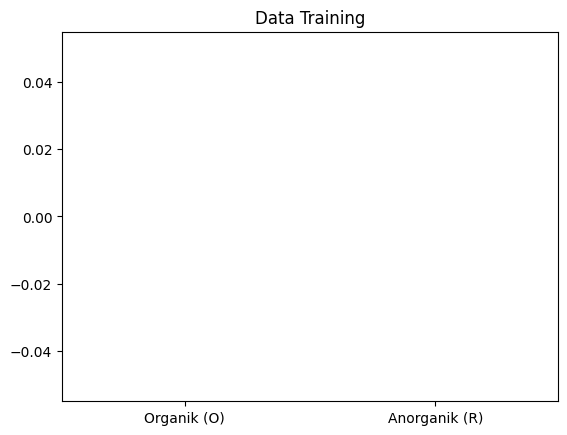

In [ ]:
train_counts = count_files(train_dir)
test_counts = count_files(test_dir)

print(f"Data Training - Organik (O): {train_counts['O']}")
print(f"Data Training - Anorganik (R): {train_counts['R']}")
print(f"Data Testing  - Organik (O): {test_counts['O']}")
print(f"Data Testing  - Anorganik (R): {test_counts['R']}")

labels = ['Organik (O)', 'Anorganik (R)']
values = [train_counts['O'], train_counts['R']]

plt.bar(labels, values, color=['green', 'gray'])
plt.title('Data Training')
plt.show()

#Cek Data Leakage

In [ ]:
def check_data_leakage(train_dir, test_dir):
    categories = ['O', 'R']
    leakage_found = False

    for cat in categories:
        train_files = set(os.listdir(os.path.join(train_dir, cat)))
        test_files = set(os.listdir(os.path.join(test_dir, cat)))

        overlap = train_files.intersection(test_files)

        print(f"Kategori {cat}:")
        print(f"- Jumlah file unik di Train: {len(train_files)}")
        print(f"- Jumlah file unik di Test: {len(test_files)}")

        if len(overlap) > 0:
            print(f"- Ditemukan {len(overlap)} file yang bocor ada di Train & Test")
            print(f"- Contoh file bocor: {list(overlap)[:5]}")
            leakage_found = True
        else:
            print("- Tidak ada kebocoran data.")
        print("-" * 30)

check_data_leakage(train_dir, test_dir)

FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/My Drive/Capstone DBS Foundation/Projects/DATASET/TRAIN/O'

# Visualisasi Sampel Gambar

In [ ]:
def display_samples(directory, categories, n_samples=3):
    plt.figure(figsize=(12, 8))

    for i, category in enumerate(categories):
        folder_path = os.path.join(directory, category)
        images = [f for f in os.listdir(folder_path) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
        sample_images = random.sample(images, n_samples)

        for j, img_name in enumerate(sample_images):
            plt.subplot(len(categories), n_samples, i * n_samples + j + 1)
            img_path = os.path.join(folder_path, img_name)
            img = mpimg.imread(img_path)
            plt.imshow(img)
            plt.title(f"Label: {category}")
            plt.axis('off')

    plt.tight_layout()
    plt.show()

display_samples(train_dir, ['O', 'R'])

# Validasi Integritas File

In [ ]:
def check_image_integrity(directory):
    corrupt_files = []
    for label in ['O', 'R']:
        folder_path = os.path.join(directory, label)
        files = os.listdir(folder_path)

        print(f"Mengecek integritas gambar di folder {label}...")
        for filename in files:
            file_path = os.path.join(folder_path, filename)
            if not os.path.isfile(file_path): continue

            # Coba baca file menggunakan OpenCV
            img = cv2.imread(file_path)
            if img is None:
                corrupt_files.append(file_path)

    return corrupt_files

# Jalankan pengecekan pada folder TRAIN
corrupt_list = check_image_integrity(train_dir)

if len(corrupt_list) == 0:
    print("\nSemua gambar valid dan dapat dibaca.")
else:
    print(f"\nDitemukan {len(corrupt_list)} file rusak.")

# Analisis Dimensi & Metadata (EDA)

In [ ]:
def analyze_dimensions(directory, label):
    folder_path = os.path.join(directory, label)
    files = [f for f in os.listdir(folder_path) if f.lower().endswith(('.png', '.jpg', '.jpeg'))][:100] # Ambil sampel 100 gambar

    widths, heights = [], []
    for filename in files:
        img = cv2.imread(os.path.join(folder_path, filename))
        if img is not None:
            h, w, _ = img.shape
            widths.append(w)
            heights.append(h)

    return widths, heights

# Mengambil data dimensi dari kelas Organik (O)
w, h = analyze_dimensions(train_dir, 'O')

print(f"Dimensi Terkecil: {min(w)}x{min(h)}")
print(f"Dimensi Terbesar: {max(w)}x{max(h)}")
print(f"Rata-rata Dimensi: {sum(w)/len(w):.0f}x{sum(h)/len(h):.0f}")

# Data Dictionary & Preprocessing

In [ ]:
# Menetapkan standar untuk Model
IMG_SIZE = 224
BATCH_SIZE = 32

# Membuat Data Dictionary Sederhana
data_info = {
    "Total Training": train_counts['O'] + train_counts['R'],
    "Total Testing": test_counts['O'] + test_counts['R'],
    "Target Size": f"{IMG_SIZE}x{IMG_SIZE}",
    "Classes": ["O (Organic)", "R (Anorganic/Recyclable)"]
}

print("Data Dictionary Dasar")
for key, value in data_info.items():
    print(f"{key}: {value}")

# Menjawab Pertanyaan Bisnis Awal
print("\nInsight Bisnis")
print(f"1. Apakah data seimbang? {'Ya' if abs(train_counts['O'] - train_counts['R']) < 500 else 'Tidak'}")
print(f"2. Solusi Utama: Menggunakan teknik Image Resizing ke {IMG_SIZE}x{IMG_SIZE} untuk standarisasi input model.")

# Definisi Augmentasi Gambar

In [ ]:
# Menentukan teknik augmentasi untuk data Training
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

test_datagen = ImageDataGenerator(rescale=1./255)

# Membuat Data Loader

In [ ]:
print("Menyiapkan Generator untuk Data Training")
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode='binary'
)

print("\nMenyiapkan Generator untuk Data Testing")
test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode='binary'
)

# Menampilkan indeks kelas untuk memastikan (O=0, R=1 atau sebaliknya)
print(f"\nIndeks Kelas: {train_generator.class_indices}")

# Verifikasi Visual Hasil Preprocessing & Augmentasi

In [ ]:
# Mengambil satu batch data (32 gambar) dari generator
images, labels = next(train_generator)

# Menampilkan 4 gambar pertama dari batch tersebut
plt.figure(figsize=(12, 12))
for i in range(4):
    plt.subplot(1, 4, i + 1)
    plt.imshow(images[i])
    plt.title(f"Label: {'R' if labels[i] == 1 else 'O'}")
    plt.axis('off')

plt.show()

print(f"Dimensi Batch: {images.shape}")
print(f"Ukuran per Gambar: {images.shape[1]}x{images.shape[2]}")

# Membuat Data Dictionary Lengkap

In [ ]:
# Membuat representasi Data Dictionary dalam bentuk DataFrame
data_dictionary = {
    "Atribut": [
        "Dataset Source", "Total Images", "Training Set", "Testing Set",
        "Image Resolution", "Color Space", "Normalization", "Augmentation"
    ],
    "Keterangan": [
        "Roboflow (sampah-jleww)", "22,500",
        f"{train_counts['O'] + train_counts['R']} gambar",
        f"{test_counts['O'] + test_counts['R']} gambar",
        "224 x 224 pixels", "RGB", "Rescale (1./255)",
        "Rotation, Zoom, Shear, Flip"
    ],
    "Fungsi": [
        "Sumber data publik", "Total populasi data", "Data untuk melatih model",
        "Data untuk evaluasi", "Standarisasi input", "Format warna",
        "Menyamakan skala pixel", "Mencegah overfitting"
    ]
}

df_dict = pd.DataFrame(data_dictionary)
print("DATA DICTIONARY PROYEK")
display(df_dict)

# Menyimpan insight akhir untuk Business Question
print("\nINSIGHT & KESIMPULAN EDA")
print("1. Permasalahan Utama: Rendahnya kesadaran memilah sampah organik/anorganik.")
print("2. Pertanyaan Bisnis: Bagaimana akurasi model dalam membedakan kedua jenis tersebut?.")
print("3. Solusi: Model Deep Learning dengan input terstandarisasi 224x224.")


### A/B TESTING - Membandingkan Dua Konfigurasi Model
- #### Model A: CNN Sederhana (tanpa augmentasi berat)
- #### Model B: CNN dengan Augmentasi Lengkap


In [ ]:
from scipy import stats
import matplotlib.pyplot as plt

# nanti ganti nilai di sini sama hasil evaluasi model yang dibikin
# Simulasi: akurasi per-batch dari 30 batch evaluasi
np.random.seed(42)

# Model A: akurasi lebih rendah & lebih tidak stabil
model_a_accuracies = np.random.normal(loc=0.82, scale=0.04, size=30)
model_a_accuracies = np.clip(model_a_accuracies, 0, 1)

# Model B: akurasi lebih tinggi
model_b_accuracies = np.random.normal(loc=0.89, scale=0.03, size=30)
model_b_accuracies = np.clip(model_b_accuracies, 0, 1)

print("RINGKASAN PERFORMA MODEL")
print(f"{'Metrik':<25} {'Model A':>12} {'Model B':>12}")
print("-" * 50)
print(f"{'Rata-rata Akurasi':<25} {model_a_accuracies.mean():>12.4f} {model_b_accuracies.mean():>12.4f}")
print(f"{'Std Deviasi':<25} {model_a_accuracies.std():>12.4f} {model_b_accuracies.std():>12.4f}")
print(f"{'Akurasi Min':<25} {model_a_accuracies.min():>12.4f} {model_b_accuracies.min():>12.4f}")
print(f"{'Akurasi Maks':<25} {model_a_accuracies.max():>12.4f} {model_b_accuracies.max():>12.4f}")

### Uji Statistik A/B Testing

In [ ]:
alpha = 0.05  # tingkat signifikansi 5%

# 1. Uji Normalitas (Shapiro-Wilk)
stat_a, p_a = stats.shapiro(model_a_accuracies)
stat_b, p_b = stats.shapiro(model_b_accuracies)

print("1. Uji Normalitas (Shapiro-Wilk)")
print(f"   Model A: statistic={stat_a:.4f}, p-value={p_a:.4f} → {'Normal' if p_a > alpha else 'Tidak Normal'}")
print(f"   Model B: statistic={stat_b:.4f}, p-value={p_b:.4f} → {'Normal' if p_b > alpha else 'Tidak Normal'}")

# 2. Pilih uji yang tepat berdasarkan normalitas
both_normal = (p_a > alpha) and (p_b > alpha)

if both_normal:
    # Gunakan Independent T-Test (parametrik)
    t_stat, p_value = stats.ttest_ind(model_a_accuracies, model_b_accuracies)
    test_name = "Independent T-Test (Parametrik)"
else:
    # Gunakan Mann-Whitney U (non-parametrik)
    t_stat, p_value = stats.mannwhitneyu(model_a_accuracies, model_b_accuracies, alternative='two-sided')
    test_name = "Mann-Whitney U Test (Non-Parametrik)"

print(f"\n2. Uji Perbadingan: {test_name}")
print(f"   Statistik uji : {t_stat:.4f}")
print(f"   P-value       : {p_value:.6f}")
print(f"   Alpha         : {alpha}")
print(f"\n   Kesimpulan    : ", end="")

if p_value < alpha:
    print(f"H0 Ditolak karena terdapat perbedaan signifikan antara Model A dan Model B (p={p_value:.4f} < α={alpha})")
    if model_b_accuracies.mean() > model_a_accuracies.mean():
        print("    Model B secara statistik LEBIH BAIK dari Model A.")
    else:
        print("    Model A secara statistik LEBIH BAIK dari Model B.")
else:
    print(f"H0 Diterima karena tidak ada perbedaan signifikan (p={p_value:.4f} > α={alpha})")

# 3. Effect Size (Cohen's d) seberapa besar perbedaannya
mean_diff = model_b_accuracies.mean() - model_a_accuracies.mean()
pooled_std = np.sqrt((model_a_accuracies.std()**2 + model_b_accuracies.std()**2) / 2)
cohens_d = mean_diff / pooled_std

print(f"\n3. Effect Size (Cohen's d): {cohens_d:.4f}")
if abs(cohens_d) < 0.2:
    effect = "Sangat Kecil"
elif abs(cohens_d) < 0.5:
    effect = "Kecil"
elif abs(cohens_d) < 0.8:
    effect = "Sedang"
else:
    effect = "Besar"
print(f"   Interpretasi: {effect}")

### Visualisasi A/B Testing

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Hasil A/B Testing: Model A vs Model B', fontsize=14, fontweight='bold')

# Plot 1: Distribusi Akurasi
axes[0].hist(model_a_accuracies, bins=10, alpha=0.6, color='steelblue', label='Model A')
axes[0].hist(model_b_accuracies, bins=10, alpha=0.6, color='tomato', label='Model B')
axes[0].axvline(model_a_accuracies.mean(), color='steelblue', linestyle='--', linewidth=2)
axes[0].axvline(model_b_accuracies.mean(), color='tomato', linestyle='--', linewidth=2)
axes[0].set_title('Distribusi Akurasi')
axes[0].set_xlabel('Akurasi')
axes[0].set_ylabel('Frekuensi')
axes[0].legend()

# Plot 2: Box Plot Perbandingan
axes[1].boxplot([model_a_accuracies, model_b_accuracies],
                labels=['Model A\n(Baseline)', 'Model B\n(Augmented)'],
                patch_artist=True,
                boxprops=dict(facecolor='lightblue'),
                medianprops=dict(color='red', linewidth=2))
axes[1].set_title('Perbandingan Box Plot')
axes[1].set_ylabel('Akurasi')
axes[1].grid(axis='y', alpha=0.3)

# Plot 3: Bar Chart Mean Std
models = ['Model A\n(Baseline)', 'Model B\n(Augmented)']
means = [model_a_accuracies.mean(), model_b_accuracies.mean()]
stds = [model_a_accuracies.std(), model_b_accuracies.std()]
colors = ['steelblue', 'tomato']

bars = axes[2].bar(models, means, yerr=stds, capsize=8, color=colors, alpha=0.8, edgecolor='black')
axes[2].set_title('Rata-rata Akurasi Std')
axes[2].set_ylabel('Akurasi')
axes[2].set_ylim(0.7, 1.0)
for bar, mean in zip(bars, means):
    axes[2].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.005,
                 f'{mean:.4f}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.savefig('ab_testing_results.png', dpi=150, bbox_inches='tight')
plt.show()

# Ringkasan akhir
print("\n" + "="*55)
print("RINGKASAN A/B TESTING")
print("="*55)
print(f"Hipotesis Null (H0)  : Model A = Model B (tidak ada perbedaan)")
print(f"Hipotesis Alternatif : Model A != Model B")
print(f"Metode Uji           : {test_name}")
print(f"P-value              : {p_value:.6f}")
print(f"Keputusan            : {'Tolak H0' if p_value < alpha else 'H0 Diterima'}")
print(f"Effect Size          : {cohens_d:.4f} ({effect})")
print(f"Rekomendasi          : {'Gunakan Model B' if model_b_accuracies.mean() > model_a_accuracies.mean() and p_value < alpha else 'Pertimbangkan trade-off kedua model'}")